## load files and define condition orders

In [3]:
import re
import sys
from glob import glob
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

import scipy

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# --- Directory containing lfads_output_*.h5 (written by run_posterior_sampling at the
#     end of 2_run_pbt_kcEXP00H.py, inside the run's best_model/ folder). ---
# Leave as None to auto-pick the most recent run; or set explicitly to a best_model dir.
H5_DIR = None
if H5_DIR is None:
    # cands = sorted(Path('../runs').glob(
        # 'kcEXP00H_multisession_202606291751/pbt/*/*/best_model'))
    cands = sorted(Path('../runs').glob(
        'kcEXP00H_multisession_202607161710/pbt/*/*/best_model'))
    cands = [c for c in cands if list(c.glob('lfads_output_*.h5'))]
    assert cands, "No best_model with lfads_output_*.h5 found under ../runs"
    H5_DIR = cands[-1]
H5_DIR = Path(H5_DIR)
print("Using LFADS outputs from:", H5_DIR)

# --- Source xarray (.nc) files: needed only for per-trial condition labels (PSTHs / colors) ---
XARRAY_DIR = (
    '../datasets/xarray_files/'
)

# The 8 stimulus conditions (V=vision, O=odor, F=forward-walk; x = off).
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
## 0.0 Load lfads outputs
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged = np.full((n_samples, *train_data.shape[1:]), np.nan, dtype=train_data.dtype)
    merged[train_inds] = train_data
    merged[valid_inds] = valid_data
    return merged

h5_paths = sorted(glob(str(H5_DIR / 'lfads_output_*.h5')))
assert h5_paths, f"No lfads_output_*.h5 in {H5_DIR}"

factors = {}
predicted_ts = {} #analogous to rates in tutorial


### claude gen below
flies = []                # h5 stems, one per fly
train_inds, valid_inds = {},{}
observed_ts, predicted_ts, factors = {}, {}, {}     # merged (n_trials, n_frames_per_trial, .) in original trial order
split = {}                # 'train'/'valid' arrays for the held-out R^2 metric
for path in h5_paths:
    fly = Path(path).stem.replace('lfads_output_lfads_', '')
    flies.append(fly)
    with h5py.File(path) as f:
        train_inds[fly] = f['train_inds'][()].astype(int) #training trial indices 
        valid_inds[fly] = f['valid_inds'][()].astype(int) #validation trial indices
        observed_ts[fly]   = merge_train_valid(f['train_recon_data'][()],
                                         f['valid_recon_data'][()],train_inds[fly], valid_inds[fly] )
        predicted_ts[fly]    = merge_train_valid(f['train_output_params'][()],
                                         f['valid_output_params'][()], train_inds[fly], valid_inds[fly] )
        factors[fly] = merge_train_valid(f['train_factors'][()],
                                         f['valid_factors'][()], train_inds[fly], valid_inds[fly] )
        # split[fly] = dict(
        #     train=(observed_ts[trf['train_recon_data'][()], f['train_output_params'][()]),
        #     valid=(f['valid_recon_data'][()], f['valid_output_params'][()]),
        # )
    print(f"  {fly}: observed_ts/pred {observed_ts[fly].shape}, factors {factors[fly].shape}")

n_fac = next(iter(factors.values())).shape[-1]
n_frames_per_trial = next(iter(factors.values())).shape[1]
print(f"\n{len(flies)} flies | n_factors = {n_fac} | n_frames_per_trial = {n_frames_per_trial}")

Using LFADS outputs from: ../runs/kcEXP00H_multisession_202607161710/pbt/kcEXP00H_multisession_KC1pt2/260716/best_model
  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 66), factors (16, 1050, 50)
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)

5 flies | n_factors = 50 | n_frames_per_trial = 1050


## fns 

In [24]:
# Compact fly labels for plotting (e.g. 'H30003-005')
def _short(fly):
    m = re.search(r'H\d+-\d+', fly)
    return m.group() if m else fly

short = {fly: _short(fly) for fly in flies}


## 0.1 remove baseline trials

In [4]:
# 1. grab the condition labels and save them in cond_by_ncstem (dict)
import xarray as xr

# condition labels keyed by .nc filename stem (e.g. 'H30003-005_..._DVAP')
cond_by_ncstem = {}
for p in sorted(glob(str(Path(XARRAY_DIR) / '*.nc'))):
    print(p)
    with xr.open_dataset(p) as ds:
        cond_by_ncstem[Path(p).stem] = \
            np.asarray(ds['condition'].values).reshape(-1).astype(str)


../datasets/xarray_files/H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc


In [5]:
# 2. from cond_by_ncstem, remove the two baseline trials "xxx" 
# and name the output "CONDITIONS"
BASELINE_TRIALS=[0,9]
conditions = {}   # fly -> (n_trials,) str
for fly_name in flies:
    num_kept_trials = observed_ts[fly_name].shape[0]
    conditions_from_xarray = cond_by_ncstem[fly_name]
    if len(conditions_from_xarray) == num_kept_trials + len(BASELINE_TRIALS):
        conditions[fly_name] = np.delete(conditions_from_xarray, BASELINE_TRIALS)
    else:
        conditions[fly_name] = conditions_from_xarray


## define colormap 

In [14]:
from matplotlib import cm
cond_cmap = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}
cond_cmap

{'VOF': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 'VOx': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 'VxF': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 'Vxx': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
 'xOF': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
 'xOx': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
 'xxF': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
 'xxx': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0)}

## Factors correlation with stimulus, loop through flies

Correlate each latent factor's time course against 0/1 indicator vectors -- one per stimulus
condition -- over the concatenated-trial time axis. Single fly (`flies[0]`), continuing from 3.2.

In [30]:
n_trials = len(conds)
x = np.arange(n_trials * n_frames_per_trial)
smask = {i: (x >= i * n_frames_per_trial) & (x < (i + 1) * n_frames_per_trial)
         for i in range(n_trials)}              # per-trial mask; also used in section 4

In [ ]:
# Step 1: extract the condition order for each fly (they are different)
for fly in flies:

    # One 0/1 indicator vector per condition over the concatenated-trial time axis.
    # Keys land in order of first occurrence, matching trial order.
    conds = conditions[fly]
    condition_vector = {}
    for i_tr, cond in enumerate(conds):
        if cond not in condition_vector:
            condition_vector[cond] = np.zeros(len(x))
        condition_vector[cond] += smask[i_tr]

    print({c: int(v.sum() // n_frames_per_trial) for c, v in condition_vector.items()},
        '= trials per condition')

{'VOx': 2, 'xOF': 2, 'VxF': 2, 'xxF': 2, 'Vxx': 2, 'xxx': 2, 'xOx': 2, 'VOF': 2} = trials per condition
{'VOF': 2, 'VOx': 2, 'xOF': 2, 'xxx': 2, 'Vxx': 2, 'VxF': 2, 'xOx': 2, 'xxF': 2} = trials per condition
{'xOF': 2, 'xxF': 2, 'Vxx': 2, 'xOx': 2, 'VOF': 2, 'VxF': 2, 'VOx': 2, 'xxx': 2} = trials per condition
{'VOx': 2, 'xOF': 2, 'Vxx': 2, 'VOF': 2, 'VxF': 2, 'xOx': 2, 'xxF': 2, 'xxx': 2} = trials per condition
{'Vxx': 2, 'VOx': 2, 'xOx': 2, 'xxx': 2, 'xxF': 2, 'VOF': 2, 'xOF': 2, 'VxF': 2} = trials per condition


In [33]:
len(COND_ORDER)

8

In [34]:
condition_vector = np.zeros((len(flies),len(COND_ORDER), len(x)))
for i_fly, fly in enumerate(flies):
    conds = conditions[fly]
    for i_cond, cond in enumerate(conds):
        condition_vector[i_fly, COND_ORDER.index(cond)] += smask[i_cond]

In [39]:
condition_vector_xr = xr.DataArray(
    condition_vector,
    dims=['fly','condition','frame'],
    coords={'fly':[short[fly] for fly in flies], 'condition':COND_ORDER},
)

In [59]:
condition_vector_xr['condition']

<xarray.DataArray 'condition' (condition: 8)> Size: 96B
array(['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx'], dtype='<U3')
Coordinates:
  * condition  (condition) <U3 96B 'VOF' 'VOx' 'VxF' 'Vxx' ... 'xOx' 'xxF' 'xxx'

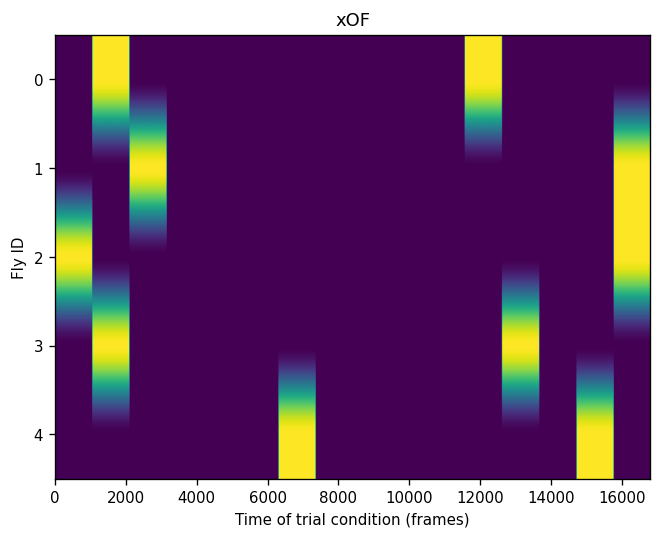

In [55]:
selected_cond = 'xOF'
plt.imshow(condition_vector_xr.sel(condition=selected_cond),aspect='auto')
plt.ylabel('Fly ID')
plt.xlabel('Time of trial condition (frames)')
plt.title(selected_cond)
plt.show()

In [50]:
# per_trial = condition_vector_xr.sel(condition='xOF').values.reshape(len(flies), n_trials, -1).mean(-1)
# plt.imshow(per_trial, aspect='auto', interpolation='nearest', vmin=0, vmax=1)
# plt.xlabel('trial')

In [ ]:
# for later
# factors_allTrials= np.array(list(factors.values())).reshape(-1,1050,50) #reshape 5*16 = 80 trials; for the decoding later

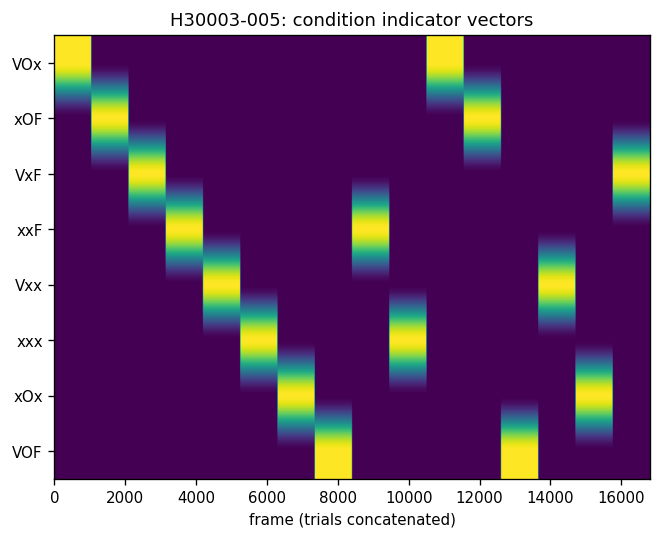

In [ ]:
plt.imshow(list(condition_vector.values()), aspect='auto')
plt.yticks(np.arange(len(condition_vector)), list(condition_vector.keys()))
plt.xlabel('frame (trials concatenated)')
plt.title(f'{short[fly]}: condition indicator vectors')
plt.show()